In [18]:
from google.colab import files

uploaded_files = files.upload()

Saving fetal_health.csv to fetal_health (1).csv


# CRISP-DM Phase 1: Objective
Fetal health monitoring using Cardiotocography (CTG) helps doctors identify fetal distress during pregnancy. This project builds a machine learning pipeline to classify CTG measurements into three states:
- **1.0 (Normal)**: Healthy fetus requiring routine care.
- **2.0 (Suspect)**: Potentially concerning patterns requiring close monitoring.
- **3.0 (Pathological)**: High-risk fetal distress requiring urgent clinical action.

*Primary Clinical Goal*: Maximize detection (Recall) of Pathological cases to avoid missing a distressed fetus.

---

# CRISP-DM Phase 2: Data Understanding (Data Inspection)
Checking dataset shape, missing values, column data types, and initial summary statistics across all 21 cardiotocography features.

In [19]:
# ============================================================
# CRISP-DM Phase 2, Part 1:
# Initial Data Understanding and Dataset Inspection
# ============================================================

from pathlib import Path
import pandas as pd
from IPython.display import display

# Improve the readability of wide outputs in Google Colab.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


def load_fetal_health_data(file_path: str | Path) -> pd.DataFrame:
    """
    Load and perform basic structural validation of the fetal health dataset.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Location of fetal_health.csv.

    Returns
    -------
    pandas.DataFrame
        Loaded and structurally validated dataset.
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Dataset not found at: {file_path}\n"
            "Upload fetal_health.csv to the Google Colab session and run again."
        )

    df = pd.read_csv(file_path)

    if df.empty:
        raise ValueError("The uploaded dataset is empty.")

    required_target = "fetal_health"

    if required_target not in df.columns:
        raise KeyError(
            f"Required target column '{required_target}' was not found."
        )

    return df


def inspect_dataset(df: pd.DataFrame) -> None:
    """
    Print the initial structural and data-quality inspection results.
    """
    print("=" * 70)
    print("1. DATASET SHAPE")
    print("=" * 70)
    print(f"Rows:    {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print(f"Predictor columns: {df.shape[1] - 1:,}")
    print()

    print("=" * 70)
    print("2. COLUMN NAMES")
    print("=" * 70)
    for position, column in enumerate(df.columns, start=1):
        print(f"{position:>2}. {column}")
    print()

    print("=" * 70)
    print("3. COLUMN DATA TYPES")
    print("=" * 70)
    print(df.dtypes.to_string())
    print()

    print("Data-type frequency:")
    print(df.dtypes.value_counts().to_string())
    print()

    print("=" * 70)
    print("4. MISSING VALUES")
    print("=" * 70)

    missing_count = df.isna().sum()
    missing_percentage = (missing_count / len(df) * 100).round(2)

    missing_report = pd.DataFrame(
        {
            "missing_count": missing_count,
            "missing_percentage": missing_percentage
        }
    )

    print(f"Total missing values: {missing_count.sum():,}")
    display(missing_report)
    print()

    print("=" * 70)
    print("5. DUPLICATE ROWS")
    print("=" * 70)

    duplicate_count = int(df.duplicated().sum())
    duplicate_percentage = duplicate_count / len(df) * 100

    print(f"Duplicate rows: {duplicate_count:,}")
    print(f"Duplicate percentage: {duplicate_percentage:.2f}%")
    print()

    print("=" * 70)
    print("6. TARGET VALIDATION")
    print("=" * 70)

    expected_target_values = {1.0, 2.0, 3.0}
    observed_target_values = set(df["fetal_health"].dropna().unique())

    print(f"Observed target values: {sorted(observed_target_values)}")

    unexpected_values = observed_target_values - expected_target_values

    if unexpected_values:
        print(f"Warning: unexpected target values found: {unexpected_values}")
    else:
        print("Target values match the expected codes: 1.0, 2.0, and 3.0.")
    print()

    print("=" * 70)
    print("7. DESCRIPTIVE SUMMARY STATISTICS")
    print("=" * 70)

    summary_statistics = df.describe().T
    display(summary_statistics)


# ------------------------------------------------------------
# Load and inspect the dataset
# ------------------------------------------------------------

DATA_PATH = Path("/content/fetal_health.csv")

# Upload fetal_health.csv to the Colab Files panel before running this cell.
df = load_fetal_health_data(DATA_PATH)
inspect_dataset(df)

1. DATASET SHAPE
Rows:    2,126
Columns: 22
Predictor columns: 21

2. COLUMN NAMES
 1. baseline value
 2. accelerations
 3. fetal_movement
 4. uterine_contractions
 5. light_decelerations
 6. severe_decelerations
 7. prolongued_decelerations
 8. abnormal_short_term_variability
 9. mean_value_of_short_term_variability
10. percentage_of_time_with_abnormal_long_term_variability
11. mean_value_of_long_term_variability
12. histogram_width
13. histogram_min
14. histogram_max
15. histogram_number_of_peaks
16. histogram_number_of_zeroes
17. histogram_mode
18. histogram_mean
19. histogram_median
20. histogram_variance
21. histogram_tendency
22. fetal_health

3. COLUMN DATA TYPES
baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                      

,missing_count,missing_percentage
baseline value,0,0.0000
accelerations,0,0.0000
fetal_movement,0,0.0000
uterine_contractions,0,0.0000
light_decelerations,0,0.0000
severe_decelerations,0,0.0000
prolongued_decelerations,0,0.0000
abnormal_short_term_variability,0,0.0000
mean_value_of_short_term_variability,0,0.0000
percentage_of_time_with_abnormal_long_term_variability,0,0.0000



5. DUPLICATE ROWS
Duplicate rows: 13
Duplicate percentage: 0.61%

6. TARGET VALIDATION
Observed target values: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
Target values match the expected codes: 1.0, 2.0, and 3.0.

7. DESCRIPTIVE SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0000,133.3039,9.8408,106.0000,126.0000,133.0000,140.0000,160.0000
accelerations,2126.0000,0.0032,0.0039,0.0000,0.0000,0.0020,0.0060,0.0190
fetal_movement,2126.0000,0.0095,0.0467,0.0000,0.0000,0.0000,0.0030,0.4810
uterine_contractions,2126.0000,0.0044,0.0029,0.0000,0.0020,0.0040,0.0070,0.0150
light_decelerations,2126.0000,0.0019,0.0030,0.0000,0.0000,0.0000,0.0030,0.0150
severe_decelerations,2126.0000,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0010
prolongued_decelerations,2126.0000,0.0002,0.0006,0.0000,0.0000,0.0000,0.0000,0.0050
abnormal_short_term_variability,2126.0000,46.9901,17.1928,12.0000,32.0000,49.0000,61.0000,87.0000
mean_value_of_short_term_variability,2126.0000,1.3328,0.8832,0.2000,0.7000,1.2000,1.7000,7.0000
percentage_of_time_with_abnormal_long_term_variability,2126.0000,9.8467,18.3969,0.0000,0.0000,0.0000,11.0000,91.0000


# CRISP-DM Phase 2: Data Understanding (Visual EDA)
Visualizing class balances, feature correlations, and distributions:
1. **Target Class Balance**: Plotting counts across Normal, Suspect, and Pathological classes.
2. **Correlation Heatmap**: Identifying top features strongest linked to fetal health.
3. **Box Plots**: Comparing key heart rate features (`abnormal_short_term_variability` and `accelerations`) across health classes.
4. **KDE Density Plots**: Comparing overall heart rate `baseline value` distributions.

Top 10 correlations with fetal_health:


,correlation
prolongued_decelerations,0.4849
abnormal_short_term_variability,0.4712
percentage_of_time_with_abnormal_long_term_variability,0.4261
accelerations,-0.3641
histogram_mode,-0.2504
histogram_mean,-0.2270
mean_value_of_long_term_variability,-0.2268
histogram_variance,0.2066
histogram_median,-0.2050
uterine_contractions,-0.2049


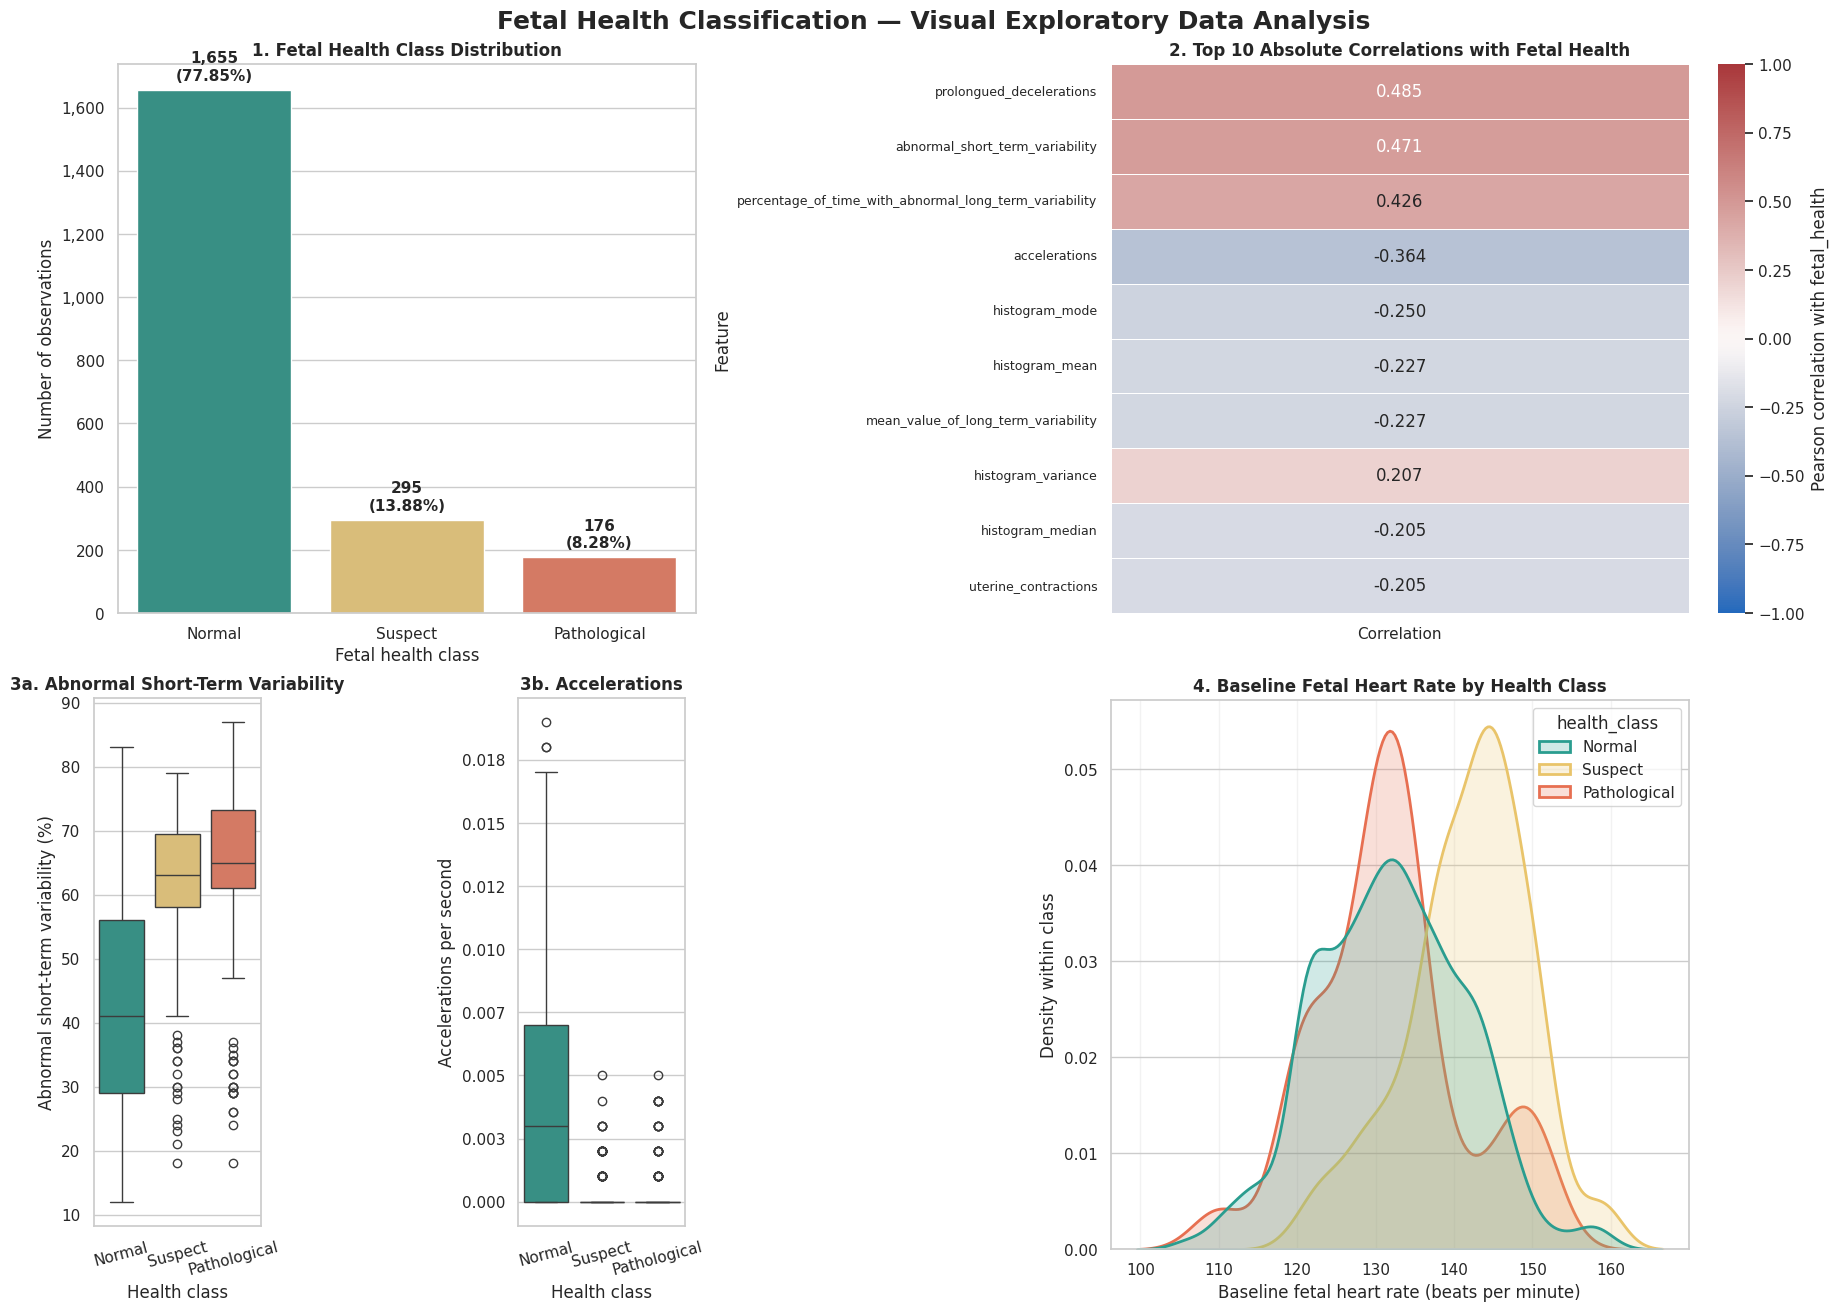

In [20]:
# ============================================================
# CRISP-DM Phase 2, Part 2:
# Visual Exploratory Data Analysis
# ============================================================

from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter, FormatStrFormatter


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

DATA_PATH = Path("/content/fetal_health.csv")
TARGET = "fetal_health"

CLASS_LABELS = {
    1.0: "Normal",
    2.0: "Suspect",
    3.0: "Pathological"
}

CLASS_ORDER = ["Normal", "Suspect", "Pathological"]

CLASS_PALETTE = {
    "Normal": "#2A9D8F",
    "Suspect": "#E9C46A",
    "Pathological": "#E76F51"
}

REQUIRED_COLUMNS = {
    TARGET,
    "abnormal_short_term_variability",
    "accelerations",
    "baseline value"
}


# ------------------------------------------------------------
# 2. Load and validate the dataset
# ------------------------------------------------------------

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Upload fetal_health.csv to the Colab Files panel."
    )

df = pd.read_csv(DATA_PATH)

if df.empty:
    raise ValueError("The dataset is empty.")

missing_columns = REQUIRED_COLUMNS.difference(df.columns)

if missing_columns:
    raise KeyError(
        f"Required columns are missing: {sorted(missing_columns)}"
    )

if df[list(REQUIRED_COLUMNS)].isna().any().any():
    raise ValueError(
        "One or more required plotting columns contain missing values."
    )

observed_classes = set(df[TARGET].unique())
unexpected_classes = observed_classes.difference(CLASS_LABELS)

if unexpected_classes:
    raise ValueError(
        f"Unexpected fetal_health codes found: {sorted(unexpected_classes)}"
    )


# Create a plotting copy so that the original data remains unchanged.
plot_df = df.copy()

plot_df["health_class"] = plot_df[TARGET].map(CLASS_LABELS)

plot_df["health_class"] = pd.Categorical(
    plot_df["health_class"],
    categories=CLASS_ORDER,
    ordered=True
)


# ------------------------------------------------------------
# 3. Calculate values needed for the visualizations
# ------------------------------------------------------------

# Class counts and percentages
class_counts = (
    plot_df["health_class"]
    .value_counts(sort=False)
)

class_percentages = (
    class_counts
    .div(len(plot_df))
    .mul(100)
)

# Rank features by the magnitude of their Pearson correlation
# with the numerically encoded target.
target_correlations = (
    df.corr(numeric_only=True)[TARGET]
    .drop(labels=TARGET)
    .sort_values(
        key=lambda correlation: correlation.abs(),
        ascending=False
    )
    .head(10)
)

print("Top 10 correlations with fetal_health:")
display(
    target_correlations
    .rename("correlation")
    .to_frame()
)


# ------------------------------------------------------------
# 4. Construct the 2x2 visualization grid
# ------------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

figure = plt.figure(
    figsize=(18, 13),
    constrained_layout=True
)

outer_grid = figure.add_gridspec(2, 2)


# ============================================================
# Chart 1: Target class distribution
# ============================================================

ax1 = figure.add_subplot(outer_grid[0, 0])

sns.countplot(
    data=plot_df,
    x="health_class",
    order=CLASS_ORDER,
    hue="health_class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    legend=False,
    ax=ax1
)

# Add count and percentage above each bar.
for bar, class_name in zip(ax1.patches, CLASS_ORDER):
    count = int(class_counts.loc[class_name])
    percentage = class_percentages.loc[class_name]

    ax1.annotate(
        text=f"{count:,}\n({percentage:.2f}%)",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax1.set_title(
    "1. Fetal Health Class Distribution",
    fontweight="bold"
)
ax1.set_xlabel("Fetal health class")
ax1.set_ylabel("Number of observations")

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{int(value):,}")
)

ax1.grid(axis="x", visible=False)


# ============================================================
# Chart 2: Top 10 target correlations
# ============================================================

ax2 = figure.add_subplot(outer_grid[0, 1])

correlation_table = target_correlations.to_frame(
    name="Correlation"
)

sns.heatmap(
    correlation_table,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Pearson correlation with fetal_health"
    },
    ax=ax2
)

ax2.set_title(
    "2. Top 10 Absolute Correlations with Fetal Health",
    fontweight="bold"
)
ax2.set_xlabel("")
ax2.set_ylabel("Feature")
ax2.tick_params(axis="y", labelsize=9)


# ============================================================
# Chart 3: Box plots
# The grid cell is divided into two axes because the variables
# have different units and substantially different scales.
# ============================================================

boxplot_grid = outer_grid[1, 0].subgridspec(
    1,
    2,
    wspace=0.18
)

ax3a = figure.add_subplot(boxplot_grid[0, 0])
ax3b = figure.add_subplot(boxplot_grid[0, 1])


# Chart 3a: Abnormal short-term variability
sns.boxplot(
    data=plot_df,
    x="health_class",
    y="abnormal_short_term_variability",
    order=CLASS_ORDER,
    hue="health_class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    legend=False,
    showfliers=True,
    ax=ax3a
)

ax3a.set_title(
    "3a. Abnormal Short-Term Variability",
    fontweight="bold"
)
ax3a.set_xlabel("Health class")
ax3a.set_ylabel("Abnormal short-term variability (%)")
ax3a.tick_params(axis="x", rotation=15)
ax3a.grid(axis="x", visible=False)


# Chart 3b: Accelerations
sns.boxplot(
    data=plot_df,
    x="health_class",
    y="accelerations",
    order=CLASS_ORDER,
    hue="health_class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    legend=False,
    showfliers=True,
    ax=ax3b
)

ax3b.set_title(
    "3b. Accelerations",
    fontweight="bold"
)
ax3b.set_xlabel("Health class")
ax3b.set_ylabel("Accelerations per second")

ax3b.yaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

ax3b.tick_params(axis="x", rotation=15)
ax3b.grid(axis="x", visible=False)


# ============================================================
# Chart 4: Baseline fetal heart-rate distributions
# ============================================================

ax4 = figure.add_subplot(outer_grid[1, 1])

sns.kdeplot(
    data=plot_df,
    x="baseline value",
    hue="health_class",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    common_norm=False,
    fill=True,
    alpha=0.22,
    linewidth=2,
    warn_singular=False,
    ax=ax4
)

ax4.set_title(
    "4. Baseline Fetal Heart Rate by Health Class",
    fontweight="bold"
)
ax4.set_xlabel(
    "Baseline fetal heart rate (beats per minute)"
)
ax4.set_ylabel("Density within class")
ax4.grid(axis="x", alpha=0.25)


# ------------------------------------------------------------
# 5. Final formatting and display
# ------------------------------------------------------------

figure.suptitle(
    "Fetal Health Classification — Visual Exploratory Data Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# CRISP-DM Phase 3: Data Preparation
## Step 3.1: Data Cleaning (Duplicate Removal)
Identifying and dropping exact duplicate patient records to prevent bias and keep evaluation honest.

In [21]:
# ============================================================
# Cell 1: Load data and remove exact duplicate rows
# ============================================================

from pathlib import Path
import pandas as pd

DATA_PATH = Path("/content/fetal_health.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Upload fetal_health.csv to the Colab Files panel."
    )

# Preserve the original dataset and work on a separate copy.
df_raw = pd.read_csv(DATA_PATH)

if df_raw.empty:
    raise ValueError("The uploaded dataset is empty.")

df = df_raw.copy()

rows_before = len(df)
duplicate_count = int(df.duplicated().sum())

# Remove rows that are identical across all columns.
df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

# Validation checks
assert rows_before - rows_after == duplicate_count
assert df.duplicated().sum() == 0

print(f"Rows before duplicate removal: {rows_before:,}")
print(f"Exact duplicate rows found:    {duplicate_count:,}")
print(f"Rows after duplicate removal:  {rows_after:,}")
print(f"Rows removed:                  {rows_before - rows_after:,}")

Rows before duplicate removal: 2,126
Exact duplicate rows found:    13
Rows after duplicate removal:  2,113
Rows removed:                  13


## Step 3.2: Target Label Remapping
Remapping target values from `{1.0, 2.0, 3.0}` to zero-indexed integers `{0, 1, 2}`:
- `0` = Normal
- `1` = Suspect
- `2` = Pathological

This conversion is required for compatibility with multi-class loss functions and neural network Softmax layers.

In [22]:
# ============================================================
# Cell 2: Convert target to zero-indexed integer labels
# ============================================================

TARGET = "fetal_health"

TARGET_MAPPING = {
    1.0: 0,  # Normal
    2.0: 1,  # Suspect
    3.0: 2   # Pathological
}

CLASS_NAMES = {
    0: "Normal",
    1: "Suspect",
    2: "Pathological"
}

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' was not found.")

observed_values = set(df[TARGET].dropna().unique())
expected_values = set(TARGET_MAPPING)

unexpected_values = observed_values - expected_values

if unexpected_values:
    raise ValueError(
        f"Unexpected target values found: {sorted(unexpected_values)}"
    )

if df[TARGET].isna().any():
    raise ValueError("The target variable contains missing values.")

# Remap and explicitly store the target as an integer.
df[TARGET] = (
    df[TARGET]
    .map(TARGET_MAPPING)
    .astype("int64")
)

# Validation checks
assert set(df[TARGET].unique()) == {0, 1, 2}
assert df[TARGET].isna().sum() == 0

print("Target mapping:")
for original_value, encoded_value in TARGET_MAPPING.items():
    print(
        f"  {original_value} -> {encoded_value} "
        f"({CLASS_NAMES[encoded_value]})"
    )

print("\nEncoded target distribution:")
target_summary = pd.DataFrame({
    "class_name": pd.Series(CLASS_NAMES),
    "count": df[TARGET].value_counts().sort_index()
})

target_summary["percentage"] = (
    target_summary["count"] / len(df) * 100
).round(2)

display(target_summary)

Target mapping:
  1.0 -> 0 (Normal)
  2.0 -> 1 (Suspect)
  3.0 -> 2 (Pathological)

Encoded target distribution:


,class_name,count,percentage
0,Normal,1646,77.9000
1,Suspect,292,13.8200
2,Pathological,175,8.2800


## Step 3.3: Stratified Train-Test Split & Feature Scaling
- **Stratified 80/20 Split**: Preserves the class proportions across both training and test sets.
- **StandardScaler**: Scales predictor features to zero mean and unit variance. Scaling is fit strictly on training data (`X_train`) and applied to testing data (`X_test`) to prevent data leakage.

In [23]:
# ============================================================
# Cell 3: Split predictors and target, then standardize features
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Separate predictors from the target.
X = df.drop(columns=[TARGET])
y = df[TARGET].copy()

if not all(pd.api.types.is_numeric_dtype(X[column]) for column in X.columns):
    raise TypeError("All predictor columns must be numeric before scaling.")

if X.isna().any().any():
    raise ValueError("Predictor variables contain missing values.")

# Keep unscaled partitions for traceability and potential tree models.
X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True
)

# Learn means and standard deviations from training data only.
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train_unscaled),
    columns=X.columns,
    index=X_train_unscaled.index
)

# Apply the training-derived parameters to unseen test data.
X_test = pd.DataFrame(
    scaler.transform(X_test_unscaled),
    columns=X.columns,
    index=X_test_unscaled.index
)

# Validation checks
assert X_train.shape[1] == X_test.shape[1] == X.shape[1]
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert set(y_train.unique()) == {0, 1, 2}
assert set(y_test.unique()) == {0, 1, 2}

print("Training-set class distribution:")
display(
    pd.DataFrame({
        "count": y_train.value_counts().sort_index(),
        "percentage": (
            y_train.value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    })
)

print("Test-set class distribution:")
display(
    pd.DataFrame({
        "count": y_test.value_counts().sort_index(),
        "percentage": (
            y_test.value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    })
)

print("Scaling completed using training-set statistics only.")

Training-set class distribution:


,count,percentage
fetal_health,,
0,1316,77.8700
1,234,13.8500
2,140,8.2800


Test-set class distribution:


,count,percentage
fetal_health,,
0,330,78.0100
1,58,13.7100
2,35,8.2700


Scaling completed using training-set statistics only.


## Step 3.4: Class Weight Calculation
Because Normal cases dominate the dataset (~78%), models can become biased toward predicting Normal. Computing inverse class weights forces models to pay extra attention to rare Pathological cases during training.

In [24]:
# ============================================================
# Cell 4: Calculate balanced class weights and report shapes
# ============================================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.sort(y_train.unique())

if set(classes) != {0, 1, 2}:
    raise ValueError(
        f"Expected training classes {{0, 1, 2}}, found {set(classes)}."
    )

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Format expected by TensorFlow/Keras model.fit(class_weight=...).
class_weights = {
    int(class_label): float(weight)
    for class_label, weight in zip(classes, weights)
}

print("Final dataset shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\nClass weights:")
print(class_weights)

print("\nClass-weight interpretation:")
for class_label, weight in class_weights.items():
    print(
        f"  {class_label} ({CLASS_NAMES[class_label]}): "
        f"{weight:.6f}"
    )

Final dataset shapes:
X_train: (1690, 21)
X_test:  (423, 21)
y_train: (1690,)
y_test:  (423,)

Class weights:
{0: 0.42806484295846, 1: 2.4074074074074074, 2: 4.023809523809524}

Class-weight interpretation:
  0 (Normal): 0.428065
  1 (Suspect): 2.407407
  2 (Pathological): 4.023810


# CRISP-DM Phase 4: Modeling
## Baseline Model 1: Random Forest Classifier
Training an ensemble of decision trees using balanced class weights. Evaluated using a confusion matrix and classification report focusing on Pathological Recall (Class 2).

RANDOM FOREST CLASSIFICATION REPORT
                  precision    recall  f1-score   support

      0 — Normal     0.9480    0.9939    0.9704       330
     1 — Suspect     0.9302    0.6897    0.7921        58
2 — Pathological     0.9706    0.9429    0.9565        35

        accuracy                         0.9480       423
       macro avg     0.9496    0.8755    0.9063       423
    weighted avg     0.9474    0.9480    0.9448       423



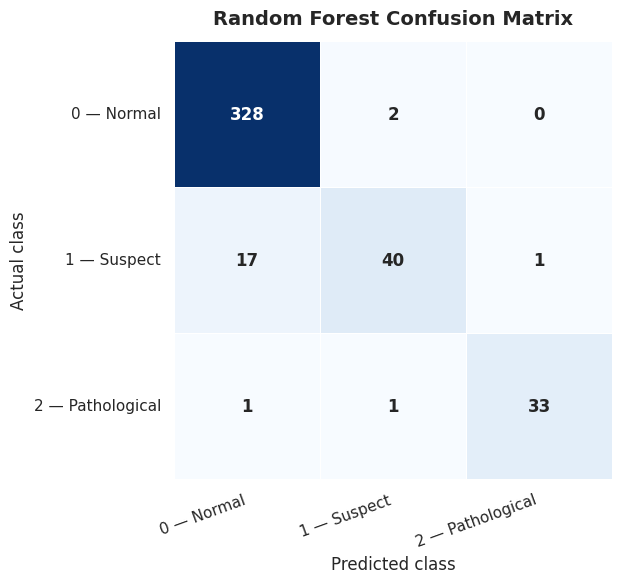

In [25]:
# ============================================================
# Cell 1: Random Forest baseline
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 42
CLASS_LABELS = [0, 1, 2]
CLASS_DISPLAY_NAMES = [
    "0 — Normal",
    "1 — Suspect",
    "2 — Pathological"
]

# Phase 3 stored the scaled matrices as X_train and X_test.
# Create the explicit names requested for this modeling phase.
if "X_train_scaled" not in globals():
    if "X_train" not in globals():
        raise NameError("Run the Phase 3 preparation cells first.")
    X_train_scaled = X_train.copy()

if "X_test_scaled" not in globals():
    if "X_test" not in globals():
        raise NameError("Run the Phase 3 preparation cells first.")
    X_test_scaled = X_test.copy()

if len(X_train_scaled) != len(y_train):
    raise ValueError("X_train_scaled and y_train have different lengths.")

if len(X_test_scaled) != len(y_test):
    raise ValueError("X_test_scaled and y_test have different lengths.")

sns.set_theme(style="whitegrid", context="notebook")

# The balanced option assigns greater importance to minority classes.
rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)

print("=" * 70)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        rf_predictions,
        labels=CLASS_LABELS,
        target_names=CLASS_DISPLAY_NAMES,
        digits=4,
        zero_division=0
    )
)

rf_confusion_matrix = confusion_matrix(
    y_test,
    rf_predictions,
    labels=CLASS_LABELS
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    rf_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.7,
    square=True,
    xticklabels=CLASS_DISPLAY_NAMES,
    yticklabels=CLASS_DISPLAY_NAMES,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=12
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Baseline Model 2: XGBoost Classifier
Training a gradient-boosted decision tree algorithm designed to handle complex feature interactions and imbalanced target classes.

XGBOOST CLASSIFICATION REPORT
                  precision    recall  f1-score   support

      0 — Normal     0.9674    0.9879    0.9775       330
     1 — Suspect     0.9388    0.7931    0.8598        58
2 — Pathological     0.9459    1.0000    0.9722        35

        accuracy                         0.9622       423
       macro avg     0.9507    0.9270    0.9365       423
    weighted avg     0.9617    0.9622    0.9609       423



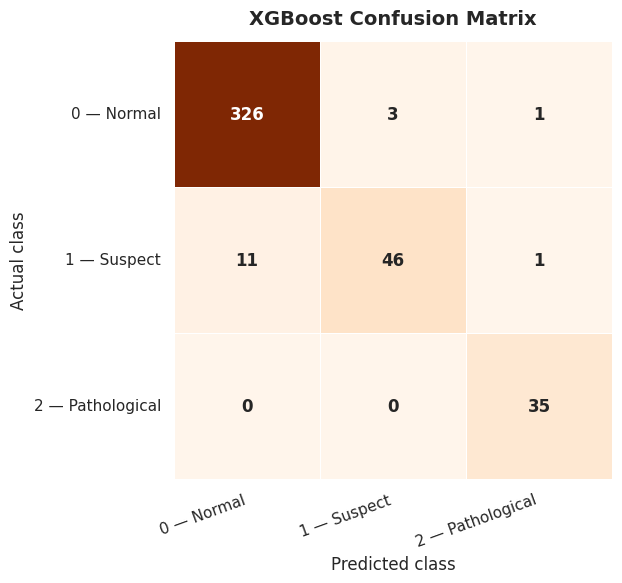

In [26]:
# ============================================================
# Cell 2: XGBoost baseline
# ============================================================

import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Reconstruct the dictionary if Cell 4 of Phase 3 was not retained.
if "class_weights" not in globals():
    observed_classes = np.sort(np.unique(y_train))

    calculated_weights = compute_class_weight(
        class_weight="balanced",
        classes=observed_classes,
        y=y_train
    )

    class_weights = {
        int(class_label): float(weight)
        for class_label, weight
        in zip(observed_classes, calculated_weights)
    }

if set(class_weights) != set(CLASS_LABELS):
    raise ValueError(
        f"Expected class weights for {CLASS_LABELS}, "
        f"but found {sorted(class_weights)}."
    )

# Assign the appropriate class weight to each training observation.
xgb_sample_weights = np.array([
    class_weights[int(class_label)]
    for class_label in np.asarray(y_train)
])

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    importance_type="gain",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train_scaled,
    y_train,
    sample_weight=xgb_sample_weights
)

xgb_predictions = xgb_model.predict(X_test_scaled)

print("=" * 70)
print("XGBOOST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        xgb_predictions,
        labels=CLASS_LABELS,
        target_names=CLASS_DISPLAY_NAMES,
        digits=4,
        zero_division=0
    )
)

xgb_confusion_matrix = confusion_matrix(
    y_test,
    xgb_predictions,
    labels=CLASS_LABELS
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    xgb_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    linewidths=0.7,
    square=True,
    xticklabels=CLASS_DISPLAY_NAMES,
    yticklabels=CLASS_DISPLAY_NAMES,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title(
    "XGBoost Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=12
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Interpretation: Feature Importance Analysis
Extracting and plotting top features driving model predictions in Random Forest and XGBoost to verify clinical relevance against medical domain knowledge.

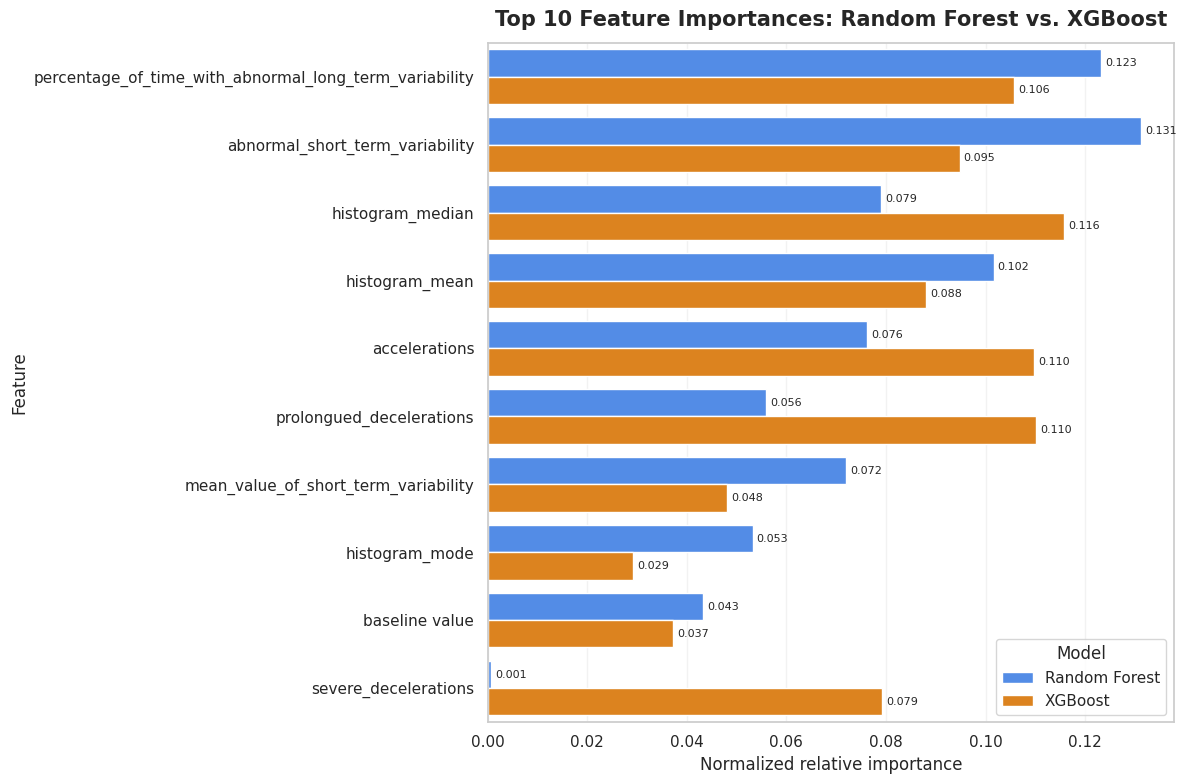

Top 10 combined feature-importance table:


,Feature,Random Forest,XGBoost,Mean importance
0,percentage_of_time_with_abnormal_long_term_var...,0.1232,0.1056,0.1144
1,abnormal_short_term_variability,0.1313,0.0948,0.1130
2,histogram_median,0.0791,0.1158,0.0975
3,histogram_mean,0.1016,0.0880,0.0948
4,accelerations,0.0761,0.1098,0.0930
5,prolongued_decelerations,0.0559,0.1101,0.0830
6,mean_value_of_short_term_variability,0.0720,0.0481,0.0600
7,histogram_mode,0.0532,0.0293,0.0412
8,baseline value,0.0432,0.0373,0.0403
9,severe_decelerations,0.0007,0.0793,0.0400


In [27]:
# ============================================================
# Cell 3: Compare Random Forest and XGBoost importances
# ============================================================

# Recover feature names from the scaled DataFrame or original X.
if hasattr(X_train_scaled, "columns"):
    feature_names = list(X_train_scaled.columns)
elif "X" in globals() and hasattr(X, "columns"):
    feature_names = list(X.columns)
else:
    raise NameError(
        "Feature names could not be recovered. "
        "Keep X_train_scaled as a DataFrame or retain X."
    )

rf_importances = np.asarray(rf_model.feature_importances_)
xgb_importances = np.asarray(xgb_model.feature_importances_)

if len(feature_names) != len(rf_importances):
    raise ValueError(
        "The number of feature names does not match "
        "the Random Forest importance array."
    )

if len(feature_names) != len(xgb_importances):
    raise ValueError(
        "The number of feature names does not match "
        "the XGBoost importance array."
    )

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Random Forest": rf_importances,
    "XGBoost": xgb_importances
})

# Normalize each model's importances to sum to one.
for model_name in ["Random Forest", "XGBoost"]:
    importance_sum = importance_df[model_name].sum()

    if importance_sum <= 0:
        raise ValueError(
            f"{model_name} returned invalid feature importances."
        )

    importance_df[model_name] /= importance_sum

# Select a common set of ten features for an honest side-by-side plot.
importance_df["Mean importance"] = importance_df[
    ["Random Forest", "XGBoost"]
].mean(axis=1)

top_10_features = (
    importance_df
    .nlargest(10, "Mean importance")
    ["Feature"]
    .tolist()
)

plot_df = (
    importance_df[
        importance_df["Feature"].isin(top_10_features)
    ]
    .melt(
        id_vars="Feature",
        value_vars=["Random Forest", "XGBoost"],
        var_name="Model",
        value_name="Relative importance"
    )
)

plt.figure(figsize=(12, 8))

importance_axis = sns.barplot(
    data=plot_df,
    x="Relative importance",
    y="Feature",
    hue="Model",
    order=top_10_features,
    orient="h",
    palette={
        "Random Forest": "#3A86FF",
        "XGBoost": "#FB8500"
    }
)

for container in importance_axis.containers:
    importance_axis.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=8
    )

plt.title(
    "Top 10 Feature Importances: Random Forest vs. XGBoost",
    fontsize=15,
    fontweight="bold",
    pad=12
)
plt.xlabel("Normalized relative importance")
plt.ylabel("Feature")
plt.legend(title="Model")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print("Top 10 combined feature-importance table:")

display(
    importance_df[
        importance_df["Feature"].isin(top_10_features)
    ]
    .sort_values("Mean importance", ascending=False)
    .reset_index(drop=True)
)

# CRISP-DM Phase 4: Modeling (Deep Learning)
## Multi-Layer Perceptron (MLP) Neural Network
Designing a feed-forward neural network tailored for tabular medical data:
- **Input Layer**: 21 units (matching CTG features).
- **Hidden Layers**: Dense layers (64, 32, 16 neurons) with ReLU activation.
- **Regularization**: Batch Normalization and Dropout (0.2–0.3) to control overfitting.
- **Output Layer**: 3 neurons with Softmax activation for multi-class probability outputs.

In [28]:
# ============================================================
# Cell 1: Neural network architecture and compilation
# ============================================================

import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization,
    Activation,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

RANDOM_STATE = 42
N_FEATURES = 21
N_CLASSES = 3

CLASS_LABELS = [0, 1, 2]
CLASS_DISPLAY_NAMES = [
    "0 — Normal",
    "1 — Suspect",
    "2 — Pathological"
]

# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    print("Deterministic TensorFlow operations are unavailable.")

# Compatibility with Phase 3 naming.
if "X_train_scaled" not in globals():
    if "X_train" not in globals():
        raise NameError("Run the Phase 3 preparation cells first.")
    X_train_scaled = X_train.copy()

if "X_test_scaled" not in globals():
    if "X_test" not in globals():
        raise NameError("Run the Phase 3 preparation cells first.")
    X_test_scaled = X_test.copy()

if X_train_scaled.shape[1] != N_FEATURES:
    raise ValueError(
        f"Expected {N_FEATURES} features, "
        f"but received {X_train_scaled.shape[1]}."
    )

if X_test_scaled.shape[1] != N_FEATURES:
    raise ValueError(
        f"Expected {N_FEATURES} test features, "
        f"but received {X_test_scaled.shape[1]}."
    )

# Clear any previously constructed Keras models.
tf.keras.backend.clear_session()

nn_model = Sequential(
    [
        Input(shape=(N_FEATURES,), name="fetal_health_features"),

        Dense(64, use_bias=False, name="dense_64"),
        BatchNormalization(name="batch_norm_64"),
        Activation("relu", name="relu_64"),
        Dropout(0.30, name="dropout_64"),

        Dense(32, use_bias=False, name="dense_32"),
        BatchNormalization(name="batch_norm_32"),
        Activation("relu", name="relu_32"),
        Dropout(0.25, name="dropout_32"),

        Dense(16, use_bias=False, name="dense_16"),
        BatchNormalization(name="batch_norm_16"),
        Activation("relu", name="relu_16"),
        Dropout(0.20, name="dropout_16"),

        Dense(
            N_CLASSES,
            activation="softmax",
            name="fetal_health_probabilities"
        )
    ],
    name="fetal_health_mlp"
)

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=[
        SparseCategoricalAccuracy(name="accuracy")
    ]
)

nn_model.summary()

Model: "fetal_health_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_64                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_32                   │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_32 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_16                   │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_16 (Activation)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fetal_health_probabilities      │ (None, 3)              │            51 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,403 (17.20 KB)

 Trainable params: 4,179 (16.32 KB)

 Non-trainable params: 224 (896.00 B)

## Deep Learning Training with Early Stopping
Training the MLP model using class weights and an `EarlyStopping` callback. If validation loss stops improving for 15 consecutive epochs, training automatically halts to prevent overfitting.

In [29]:
# ============================================================
# Cell 2: Train with class weights and early stopping
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

VALIDATION_SPLIT = 0.15
MAX_EPOCHS = 100
BATCH_SIZE = 32

# Phase 3 used the variable name class_weights.
if "class_weight" not in globals():
    if "class_weights" not in globals():
        raise NameError(
            "Run the Phase 3 class-weight calculation cell first."
        )
    class_weight = class_weights.copy()

# Ensure Keras receives ordinary Python integer keys and float values.
class_weight = {
    int(class_label): float(weight)
    for class_label, weight in class_weight.items()
}

if set(class_weight) != set(CLASS_LABELS):
    raise ValueError(
        f"Expected class-weight keys {CLASS_LABELS}, "
        f"but found {sorted(class_weight)}."
    )

# Convert inputs to TensorFlow-friendly arrays.
X_train_nn = np.asarray(
    X_train_scaled,
    dtype=np.float32
)

y_train_nn = np.asarray(
    y_train,
    dtype=np.int32
)

# Keras selects the validation fraction before epoch-level shuffling.
# Pre-shuffle once reproducibly to avoid an ordered validation tail.
rng = np.random.default_rng(RANDOM_STATE)
training_order = rng.permutation(len(y_train_nn))

X_train_nn = X_train_nn[training_order]
y_train_nn = y_train_nn[training_order]

# Verify that the validation tail contains all three classes.
split_index = int(
    len(y_train_nn) * (1 - VALIDATION_SPLIT)
)

validation_labels = y_train_nn[split_index:]

if set(np.unique(validation_labels)) != set(CLASS_LABELS):
    raise ValueError(
        "The validation subset does not contain all three classes. "
        "Use an explicit stratified validation split instead."
    )

print("Class weights used during training:")
print(class_weight)

print("\nApproximate validation-class distribution:")
validation_distribution = pd.Series(
    validation_labels
).value_counts().sort_index()

display(
    pd.DataFrame({
        "class_name": [
            "Normal",
            "Suspect",
            "Pathological"
        ],
        "count": validation_distribution.reindex(
            CLASS_LABELS,
            fill_value=0
        ).values,
        "percentage": (
            validation_distribution.reindex(
                CLASS_LABELS,
                fill_value=0
            )
            .div(len(validation_labels))
            .mul(100)
            .round(2)
            .values
        )
    },
    index=CLASS_LABELS)
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = nn_model.fit(
    X_train_nn,
    y_train_nn,
    validation_split=VALIDATION_SPLIT,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

epochs_completed = len(history.history["loss"])
best_epoch = int(
    np.argmin(history.history["val_loss"]) + 1
)

print(f"\nEpochs completed: {epochs_completed}")
print(f"Best validation-loss epoch: {best_epoch}")

Class weights used during training:
{0: 0.42806484295846, 1: 2.4074074074074074, 2: 4.023809523809524}

Approximate validation-class distribution:


,class_name,count,percentage
0,Normal,195,76.7700
1,Suspect,27,10.6300
2,Pathological,32,12.6000


Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3614 - loss: 1.1114 - val_accuracy: 0.4724 - val_loss: 1.0164
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4749 - loss: 0.9035 - val_accuracy: 0.5354 - val_loss: 0.9272
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5975 - loss: 0.7813 - val_accuracy: 0.6575 - val_loss: 0.8440
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6240 - loss: 0.7838 - val_accuracy: 0.6654 - val_loss: 0.7713
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6838 - loss: 0.7253 - val_accuracy: 0.7087 - val_loss: 0.7015
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7124 - loss: 0.6671 - val_accuracy: 0.7441 - val_loss: 0.6561
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7326 - loss: 0.6730 - val_accuracy: 0.7795 - val_loss: 0.5998
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7347 - loss: 0.6595 - val_accuracy: 0.7992 - 

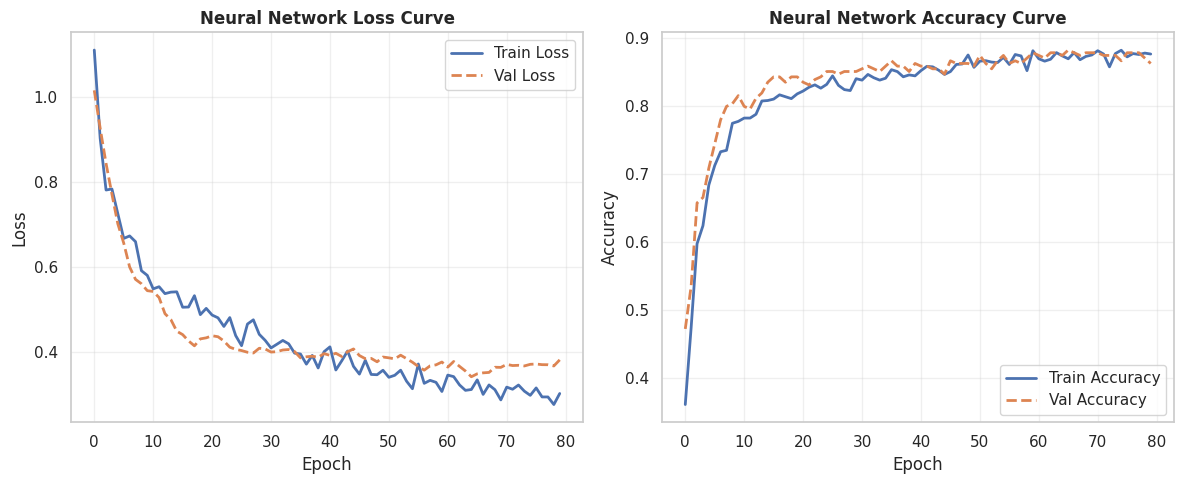

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(
    history.history["val_loss"],
    label="Val Loss",
    linewidth=2,
    linestyle="--",
)
plt.title("Neural Network Loss Curve", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(
    history.history["val_accuracy"],
    label="Val Accuracy",
    linewidth=2,
    linestyle="--",
)
plt.title("Neural Network Accuracy Curve", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mlp_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## Deep Learning Learning Curves & Evaluation
Plotting Training vs. Validation Loss and Accuracy curves to confirm stable model convergence without overfitting. Evaluated on test data using a confusion matrix.

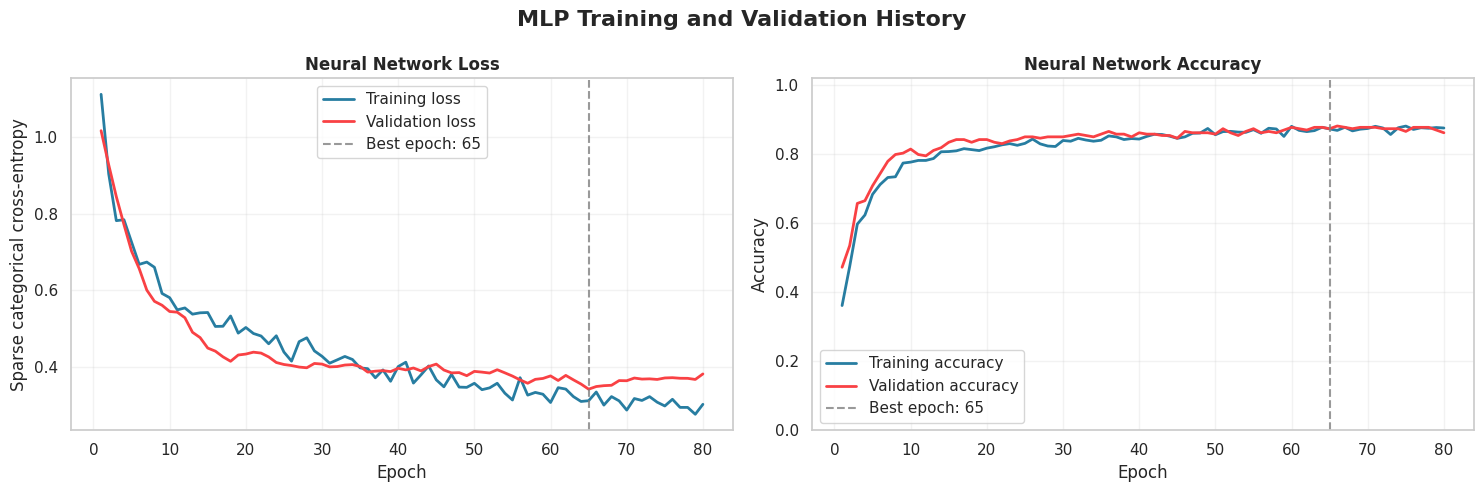

NEURAL NETWORK CLASSIFICATION REPORT
                  precision    recall  f1-score   support

      0 — Normal     0.9900    0.9000    0.9429       330
     1 — Suspect     0.5977    0.8966    0.7172        58
2 — Pathological     0.8056    0.8286    0.8169        35

        accuracy                         0.8936       423
       macro avg     0.7978    0.8750    0.8257       423
    weighted avg     0.9209    0.8936    0.9015       423

Example softmax probabilities (%):


,Normal probability (%),Suspect probability (%),Pathological probability (%)
0,99.5100,0.4700,0.0200
1,99.0500,0.5200,0.4300
2,2.2600,72.3500,25.3900
3,99.9300,0.0600,0.0100
4,99.9100,0.0800,0.0200


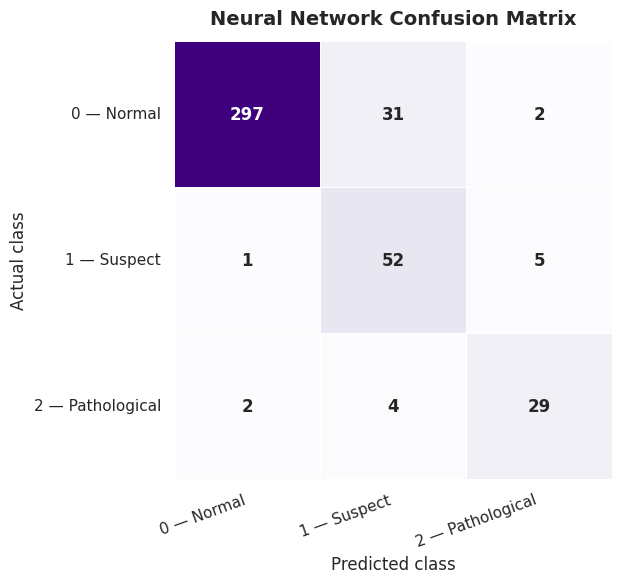

In [31]:
# ============================================================
# Cell 3: Learning curves and test-set evaluation
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid", context="notebook")

history_df = pd.DataFrame(history.history)
epoch_numbers = np.arange(1, len(history_df) + 1)

# ------------------------------------------------------------
# Training-history curves
# ------------------------------------------------------------

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].plot(
    epoch_numbers,
    history_df["loss"],
    label="Training loss",
    linewidth=2,
    color="#277DA1"
)
axes[0].plot(
    epoch_numbers,
    history_df["val_loss"],
    label="Validation loss",
    linewidth=2,
    color="#F94144"
)
axes[0].axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    alpha=0.8,
    label=f"Best epoch: {best_epoch}"
)
axes[0].set_title("Neural Network Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    epoch_numbers,
    history_df["accuracy"],
    label="Training accuracy",
    linewidth=2,
    color="#277DA1"
)
axes[1].plot(
    epoch_numbers,
    history_df["val_accuracy"],
    label="Validation accuracy",
    linewidth=2,
    color="#F94144"
)
axes[1].axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    alpha=0.8,
    label=f"Best epoch: {best_epoch}"
)
axes[1].set_title("Neural Network Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.25)

figure.suptitle(
    "MLP Training and Validation History",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Test-set predictions
# ------------------------------------------------------------

X_test_nn = np.asarray(
    X_test_scaled,
    dtype=np.float32
)

y_test_nn = np.asarray(
    y_test,
    dtype=np.int32
)

nn_probabilities = nn_model.predict(
    X_test_nn,
    verbose=0
)

nn_predictions = np.argmax(
    nn_probabilities,
    axis=1
)

# Probability-output validation
assert nn_probabilities.shape == (len(X_test_nn), N_CLASSES)
assert np.allclose(
    nn_probabilities.sum(axis=1),
    1.0,
    atol=1e-5
)

print("=" * 70)
print("NEURAL NETWORK CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test_nn,
        nn_predictions,
        labels=CLASS_LABELS,
        target_names=CLASS_DISPLAY_NAMES,
        digits=4,
        zero_division=0
    )
)

# Preserve structured metrics for the final comparison.
nn_report = classification_report(
    y_test_nn,
    nn_predictions,
    labels=CLASS_LABELS,
    target_names=CLASS_DISPLAY_NAMES,
    output_dict=True,
    zero_division=0
)

print("Example softmax probabilities (%):")

probability_preview = pd.DataFrame(
    nn_probabilities[:5] * 100,
    columns=[
        "Normal probability (%)",
        "Suspect probability (%)",
        "Pathological probability (%)"
    ]
)

display(probability_preview.round(2))

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

nn_confusion_matrix = confusion_matrix(
    y_test_nn,
    nn_predictions,
    labels=CLASS_LABELS
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    nn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    linewidths=0.7,
    square=True,
    xticklabels=CLASS_DISPLAY_NAMES,
    yticklabels=CLASS_DISPLAY_NAMES,
    annot_kws={
        "size": 12,
        "weight": "bold"
    }
)

plt.title(
    "Neural Network Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=12
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# CRISP-DM Phase 5: Evaluation
## Multi-Class Receiver Operating Characteristic (ROC) Curves
Comparing classification performance across all 3 models (Random Forest, XGBoost, and Deep Learning MLP) using One-vs-Rest (OvR) ROC curves and Area Under the Curve (AUC) metrics for each health class.

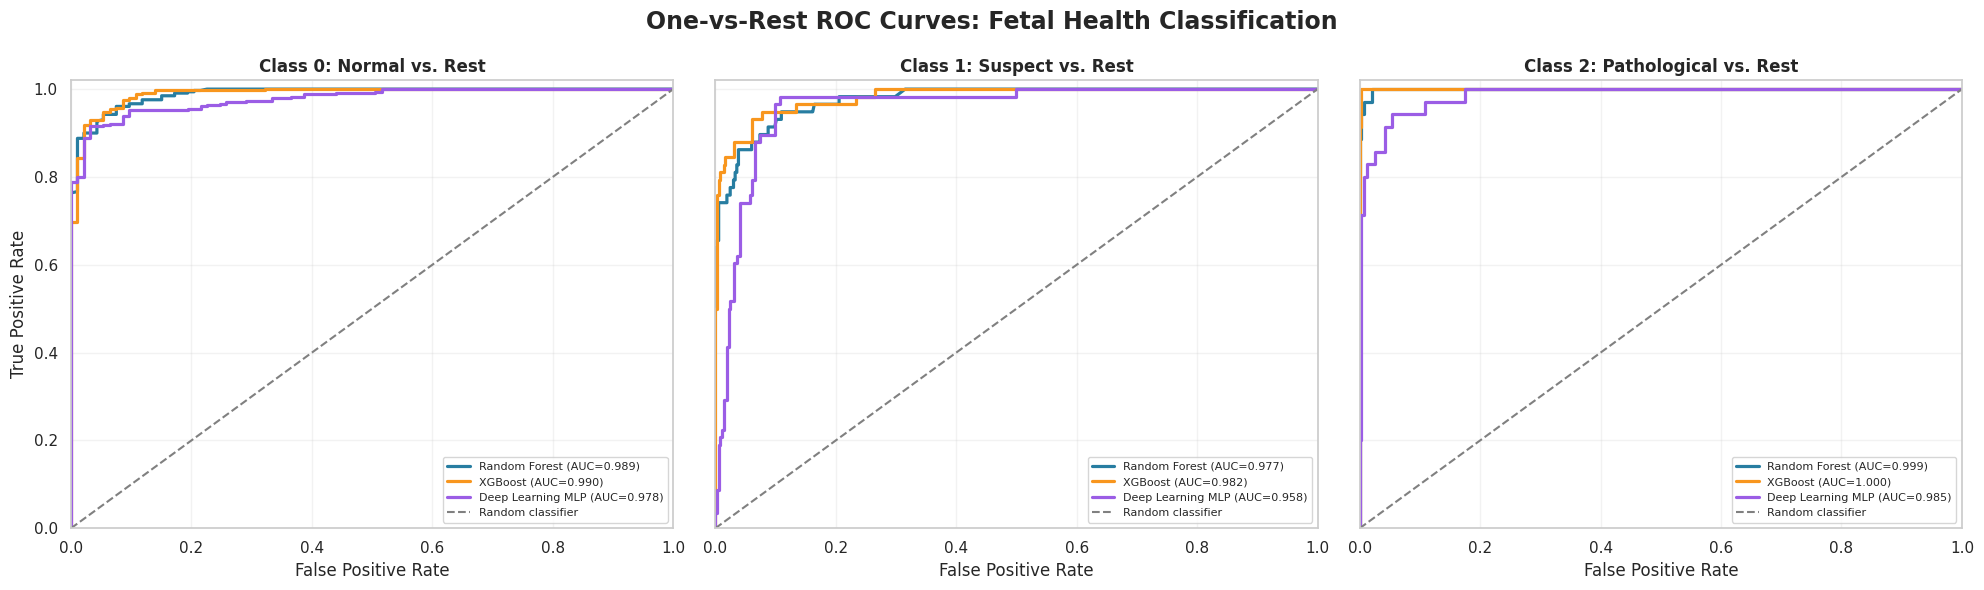

One-vs-Rest AUC scores by class:


,Class 0 — Normal,Class 1 — Suspect,Class 2 — Pathological
Model,,,
Random Forest,0.9891,0.9766,0.9990
XGBoost,0.9898,0.9821,0.9998
Deep Learning MLP,0.9775,0.9580,0.9849


In [32]:
# ============================================================
# Cell 1: One-vs-Rest multiclass ROC-AUC evaluation
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

CLASS_LABELS = [0, 1, 2]

CLASS_NAMES = {
    0: "Normal",
    1: "Suspect",
    2: "Pathological"
}

MODEL_COLORS = {
    "Random Forest": "#277DA1",
    "XGBoost": "#F8961E",
    "Deep Learning MLP": "#9B5DE5"
}

# Confirm that all required notebook objects are available.
required_objects = [
    "rf_model",
    "xgb_model",
    "nn_model",
    "X_test_scaled",
    "y_test"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the earlier preparation and modeling cells first. "
        f"Missing objects: {missing_objects}"
    )

# Confirm probability-column order for the scikit-learn models.
for model_name, model in {
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}.items():
    if not np.array_equal(
        np.asarray(model.classes_),
        np.asarray(CLASS_LABELS)
    ):
        raise ValueError(
            f"{model_name} probability columns do not follow "
            "the expected class order [0, 1, 2]."
        )

y_test_array = np.asarray(
    y_test,
    dtype=np.int32
)

X_test_nn = np.asarray(
    X_test_scaled,
    dtype=np.float32
)

# Obtain one probability column per class from every model.
model_probabilities = {
    "Random Forest": np.asarray(
        rf_model.predict_proba(X_test_scaled)
    ),
    "XGBoost": np.asarray(
        xgb_model.predict_proba(X_test_scaled)
    ),
    "Deep Learning MLP": np.asarray(
        nn_model.predict(X_test_nn, verbose=0)
    )
}

# Validate all probability matrices.
for model_name, probabilities in model_probabilities.items():
    expected_shape = (len(y_test_array), len(CLASS_LABELS))

    if probabilities.shape != expected_shape:
        raise ValueError(
            f"{model_name} returned shape {probabilities.shape}; "
            f"expected {expected_shape}."
        )

    if not np.isfinite(probabilities).all():
        raise ValueError(
            f"{model_name} returned non-finite probabilities."
        )

    if not np.allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-4
    ):
        raise ValueError(
            f"{model_name} probability rows do not sum to one."
        )

# Convert integer labels into three binary One-vs-Rest columns.
y_test_binarized = label_binarize(
    y_test_array,
    classes=CLASS_LABELS
)

sns.set_theme(style="whitegrid", context="notebook")

figure, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

# Store class-specific AUC values for reporting.
ovr_auc_scores = {
    model_name: {}
    for model_name in model_probabilities
}

for class_index, axis in enumerate(axes):
    binary_actual = y_test_binarized[:, class_index]

    for model_name, probabilities in model_probabilities.items():
        false_positive_rate, true_positive_rate, _ = roc_curve(
            binary_actual,
            probabilities[:, class_index]
        )

        class_auc = auc(
            false_positive_rate,
            true_positive_rate
        )

        column_name = (
            f"Class {class_index} — "
            f"{CLASS_NAMES[class_index]}"
        )

        ovr_auc_scores[model_name][column_name] = class_auc

        axis.plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=2.3,
            color=MODEL_COLORS[model_name],
            label=f"{model_name} (AUC={class_auc:.3f})"
        )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.5,
        color="gray",
        label="Random classifier"
    )

    axis.set_title(
        f"Class {class_index}: "
        f"{CLASS_NAMES[class_index]} vs. Rest",
        fontweight="bold"
    )
    axis.set_xlabel("False Positive Rate")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.legend(
        loc="lower right",
        fontsize=8
    )
    axis.grid(alpha=0.25)

axes[0].set_ylabel("True Positive Rate")

figure.suptitle(
    "One-vs-Rest ROC Curves: Fetal Health Classification",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Display exact per-class AUC values.
per_class_auc_table = (
    pd.DataFrame(ovr_auc_scores)
    .T
    .rename_axis("Model")
)

print("One-vs-Rest AUC scores by class:")

display(
    per_class_auc_table.style
    .format("{:.4f}")
    .background_gradient(
        cmap="YlGn",
        axis=None,
        vmin=0.50,
        vmax=1.00
    )
)

# CRISP-DM Phase 6: Deployment & Executive Summary
## Unified Performance Scorecard & Clinical Recommendation
Comparing all models head-to-head on Test Accuracy, Macro F1-Score, and Pathological Recall (Class 2) to select the optimal model for clinical risk screening.

In [33]:
# ============================================================
# Cell 2: Unified scorecard and deployment recommendation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Convert probabilities into predicted classes.
model_predictions = {
    model_name: np.argmax(probabilities, axis=1)
    for model_name, probabilities
    in model_probabilities.items()
}

scorecard_rows = []
clinical_error_rows = []

for model_name in model_probabilities:
    predictions = model_predictions[model_name]
    probabilities = model_probabilities[model_name]

    test_accuracy = accuracy_score(
        y_test_array,
        predictions
    )

    macro_precision = precision_score(
        y_test_array,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test_array,
        predictions,
        average="macro",
        zero_division=0
    )

    pathological_recall = recall_score(
        y_test_array,
        predictions,
        labels=[2],
        average=None,
        zero_division=0
    )[0]

    macro_f1 = f1_score(
        y_test_array,
        predictions,
        average="macro",
        zero_division=0
    )

    multiclass_roc_auc = roc_auc_score(
        y_test_array,
        probabilities,
        labels=CLASS_LABELS,
        multi_class="ovr",
        average="macro"
    )

    scorecard_rows.append({
        "Model": model_name,
        "Test Accuracy": test_accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Pathological Recall": pathological_recall,
        "Macro F1-Score": macro_f1,
        "Multi-Class ROC-AUC": multiclass_roc_auc
    })

    actual_pathological = y_test_array == 2
    predicted_pathological = predictions == 2

    pathological_false_negatives = int(
        np.sum(
            actual_pathological
            & ~predicted_pathological
        )
    )

    pathological_false_positives = int(
        np.sum(
            ~actual_pathological
            & predicted_pathological
        )
    )

    clinical_error_rows.append({
        "Model": model_name,
        "Pathological False Negatives":
            pathological_false_negatives,
        "Pathological False Positives":
            pathological_false_positives
    })

scorecard = (
    pd.DataFrame(scorecard_rows)
    .set_index("Model")
)

clinical_error_audit = (
    pd.DataFrame(clinical_error_rows)
    .set_index("Model")
)

# Safety-first model selection.
ranked_models = scorecard.sort_values(
    by=[
        "Pathological Recall",
        "Macro F1-Score",
        "Macro Recall",
        "Multi-Class ROC-AUC"
    ],
    ascending=False
)

winning_model_name = ranked_models.index[0]

scorecard["Recommendation"] = np.where(
    scorecard.index == winning_model_name,
    "WINNER — advance to clinical validation",
    "Not selected"
)

# Display the winning model first.
scorecard = scorecard.loc[ranked_models.index]
clinical_error_audit = clinical_error_audit.loc[
    ranked_models.index
]

metric_columns = [
    "Test Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Pathological Recall",
    "Macro F1-Score",
    "Multi-Class ROC-AUC"
]

def highlight_winning_row(row):
    if row.name == winning_model_name:
        return [
            "background-color: #D9EAD3; "
            "font-weight: bold; color: #1B4332"
        ] * len(row)

    return [""] * len(row)

styled_scorecard = (
    scorecard.style
    .format({
        column: "{:.4f}"
        for column in metric_columns
    })
    .apply(
        highlight_winning_row,
        axis=1
    )
    .set_caption(
        "Unified Test-Set Performance Scorecard"
    )
)

print("Model-selection rule:")
print(
    "Highest Pathological recall, followed by "
    "macro F1, macro recall, and multiclass ROC-AUC."
)

print(f"\nRecommended validation candidate: {winning_model_name}")

display(styled_scorecard)

print("\nClinical error audit:")
display(clinical_error_audit)

winner_metrics = scorecard.loc[winning_model_name]

print("\nFinal data-driven recommendation:")
print(
    f"Advance {winning_model_name} as the candidate model. "
    f"It achieved Pathological recall of "
    f"{winner_metrics['Pathological Recall']:.4f} and "
    f"macro F1 of "
    f"{winner_metrics['Macro F1-Score']:.4f}."
)

print(
    "This recommendation is for controlled external clinical "
    "validation, not immediate autonomous clinical deployment."
)

Model-selection rule:
Highest Pathological recall, followed by macro F1, macro recall, and multiclass ROC-AUC.

Recommended validation candidate: XGBoost


,Test Accuracy,Macro Precision,Macro Recall,Pathological Recall,Macro F1-Score,Multi-Class ROC-AUC,Recommendation
Model,,,,,,,
XGBoost,0.9622,0.9507,0.9270,1.0000,0.9365,0.9905,WINNER — advance to clinical validation
Random Forest,0.9480,0.9496,0.8755,0.9429,0.9063,0.9883,Not selected
Deep Learning MLP,0.8936,0.7978,0.8750,0.8286,0.8257,0.9735,Not selected



Clinical error audit:


,Pathological False Negatives,Pathological False Positives
Model,,
XGBoost,0,2
Random Forest,2,1
Deep Learning MLP,6,7



Final data-driven recommendation:
Advance XGBoost as the candidate model. It achieved Pathological recall of 1.0000 and macro F1 of 0.9365.
This recommendation is for controlled external clinical validation, not immediate autonomous clinical deployment.
